# Serrodyne Waveform in QICK (tProc-based)

This notebook ports the piecewise serrodyne sawtooth generator from `firmware.signals.serrodyne` (used in the RFSoC4x2 AWG overlay / `02_serrodyne.ipynb`) into the **QICK** tProc-based framework, using the same connect/trigger/play/acquire pattern as `00_Send_receive_pulse.ipynb`.

Key differences from the bare-metal `OverlayController` (PYNQ) approach:

- Instead of writing the waveform directly into a BRAM player and toggling a GPIO enable, we load the serrodyne waveform as an **arbitrary envelope** into a QICK signal-generator channel with `add_envelope()`.
- We use `outsel="input"` so the generator outputs the envelope samples directly (no DDS multiplication), since the serrodyne waveform we generate already contains the desired phase-ramp/frequency content -- exactly like the direct-BRAM-playback model in the AWG overlay.
- Triggering, playing, and readout use the standard QICK `AveragerProgram` / `measure()` pattern (as in `00_Send_receive_pulse.ipynb`), so you get loopback capture (via the ADC) for free, which is useful for verifying the waveform on real hardware.

Adjust `GEN_CH` / `RO_CH` below for your board/firmware (see the printed QICK config).

In [2]:
# Import the QICK drivers and auxiliary libraries
from qick import *
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

/usr/local/share/pynq-venv/lib/python3.10/site-packages/pydantic/_internal/_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'underscore_attrs_are_private' has been removed
  warnings.warn(message, UserWarning)
/usr/local/share/pynq-venv/lib/python3.10/site-packages/pydantic/_internal/_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'underscore_attrs_are_private' has been removed
  warnings.warn(message, UserWarning)


In [3]:
# Load bitstream and print the QICK configuration
soc = QickSoc()
soccfg = soc
print(soccfg)

QICK running on RFSoC4x2, software version 0.2.422

Firmware configuration (built Wed Sep  6 18:49:29 2023):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0], [DAC tile 2], [ADC tile 0]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_A

	2 readout channels:
	0:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.0 (no edge counter, no weights)
		memory 16384 accumulated, 1024 decimated (1.852 us)
		triggered by output 7, pin 14, feedback to tProc input 0
		ADC tile 0, blk 0 is ADC_D
	1:	axis_readout_v

### Hardware configuration

Set `GEN_CH` to the signal-generator channel driving your EOM/AOM path, and `RO_CH` to a readout channel you can use for loopback verification (cable a DAC output into an ADC input, or just leave this and ignore the acquired trace if you don't have a loopback connection).

In [4]:
GEN_CH = 0
RO_CH = 0

## Serrodyne waveform generator

This is a standalone port of `firmware.signals.serrodyne` (and its `time_axis` helper), so this notebook has no dependency on the `firmware` / `OverlayController` package -- it only needs `numpy` and `scipy`.

In [5]:
from scipy import signal as scipy_signal


def time_axis(num_samples, sample_rate):
    """Return a time axis in seconds."""
    return np.arange(int(num_samples), dtype=float) / float(sample_rate)


def serrodyne(
    ratios,
    freqs_hz,
    total_seconds,
    *,
    amplitude,
    sample_rate,
    max_points=None,
    width=1.0,
    continuous_phase=False,
):
    """Generate a piecewise serrodyne sawtooth waveform.

    Ported from firmware.signals.serrodyne (RFSoC4x2 AWG overlay).
    """
    if len(ratios) != len(freqs_hz):
        raise ValueError("ratios and frequencies must have same length")
    if total_seconds <= 0:
        raise ValueError("total_seconds must be > 0")
    if not (0.0 <= width <= 1.0):
        raise ValueError("width must be in [0, 1]")

    sample_rate = float(sample_rate)
    n_samples = max(1, int(round(float(total_seconds) * sample_rate)))
    if max_points is not None:
        n_samples = min(n_samples, int(max_points))
    dt = 1.0 / sample_rate

    ratio_sum = sum(ratios)
    segment_lengths = [int(round(n_samples * (ratio / ratio_sum))) for ratio in ratios]
    delta = n_samples - sum(segment_lengths)
    index = 0
    while delta != 0 and index < len(segment_lengths) * 4:
        segment_index = index % len(segment_lengths)
        candidate = segment_lengths[segment_index] + (1 if delta > 0 else -1)
        if candidate >= 0:
            segment_lengths[segment_index] = candidate
            delta = n_samples - sum(segment_lengths)
        index += 1

    x = time_axis(n_samples, sample_rate)
    y = np.zeros(n_samples, dtype=float)
    start = 0
    phase_offset = 0.0
    two_pi = 2 * np.pi

    for length, frequency in zip(segment_lengths, freqs_hz):
        end = start + length
        if length > 0:
            t = time_axis(length, sample_rate)
            if frequency == 0:
                segment = np.zeros(length)
                if continuous_phase:
                    phase_offset = phase_offset % two_pi
            else:
                phase = (two_pi * float(frequency) * t) + (phase_offset if continuous_phase else 0.0)
                segment = float(amplitude) * (scipy_signal.sawtooth(phase, width=float(width))) 
                if continuous_phase:
                    phase_offset = (two_pi * float(frequency) * (length * dt) + phase_offset) % two_pi
            y[start:end] = segment
        start = end

    return x, y, n_samples

## Generate a serrodyne waveform sized for this generator

QICK signal-generator envelopes are played at `f_fabric * samps_per_clk` samples/sec, and the envelope length must be a multiple of `samps_per_clk`. We generate the serrodyne waveform at that sample rate, then zero-pad up to the next valid length.

In [6]:
gencfg = soccfg["gens"][GEN_CH]
samps_per_clk = gencfg["samps_per_clk"]
ENV_SR = gencfg["f_fabric"] * samps_per_clk * 1e6  # envelope sample rate, in Hz

print(f"Generator {GEN_CH}: f_fabric={gencfg['f_fabric']:.3f} MHz, "
      f"samps_per_clk={samps_per_clk}, envelope sample rate={ENV_SR/1e9:.4f} GSPS")

Generator 0: f_fabric=614.400 MHz, samps_per_clk=16, envelope sample rate=9.8304 GSPS


In [ ]:
# Serrodyne segments: (ratio, frequency in Hz), same convention as 02_serrodyne.ipynb
ratios = [0.337, 0.167, 0.288, 0.208]
actual_freq_shift = np.array([-76.25e6, 0, +122.92e6-76.25e6, +147.82e6-76.25e6]) 
freqs_hz = actual_freq_shift*(-1) # due to signal being flipped when measured
requested_total_seconds = 1.0e-6

x, y, n_samples = serrodyne(
    ratios,
    freqs_hz,
    requested_total_seconds,
    amplitude=1,
    sample_rate=ENV_SR,
    continuous_phase=True,
)

# Zero-pad to a valid envelope length (multiple of samps_per_clk)
pad = (-len(y)) % samps_per_clk
if pad:
    y = np.concatenate([y, np.zeros(pad)])

actual_total_seconds = len(y) / ENV_SR

print(f"Requested serrodyne period: {requested_total_seconds * 1e6:.6f} us")
print(f"Active samples: {n_samples}, padded to {len(y)} (multiple of {samps_per_clk})")
print(f"Actual serrodyne period: {actual_total_seconds * 1e6:.6f} us")

Requested serrodyne period: 1.000000 us
Active samples: 9830, padded to 9840 (multiple of 16)
Actual serrodyne period: 1.000977 us


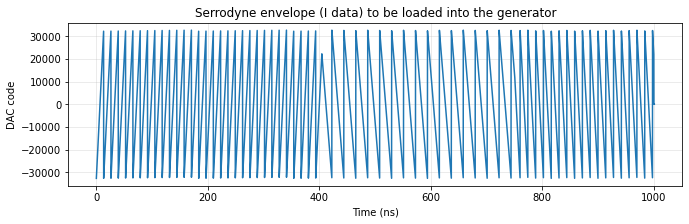

In [17]:
# Convert to int16 envelope data, scaled to this generator's max envelope amplitude
maxv = soccfg.get_maxv(GEN_CH)
idata = np.round(y * maxv).astype(np.int16)
qdata = np.zeros_like(idata)

fig, ax = plt.subplots(figsize=(11, 3))
t_ns = np.arange(len(idata)) / ENV_SR * 1e9
ax.plot(t_ns, idata)
ax.set_title("Serrodyne envelope (I data) to be loaded into the generator")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("DAC code")
ax.grid(True, alpha=0.3)

## Define the QICK program

This follows the same `initialize()` / `body()` structure as `LoopbackProgram` in `00_Send_receive_pulse.ipynb`: declare the generator and readout, load the envelope, set up the pulse, then trigger + play + wait inside `measure()`.

We use `outsel="input"` so the DAC plays the envelope samples directly (the serrodyne waveform already encodes the desired phase ramp), rather than multiplying by the generator's internal DDS.

In [18]:
class SerrodyneProgram(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        res_ch = cfg["res_ch"]

        # set the nyquist zone
        self.declare_gen(ch=res_ch, nqz=1)

        # configure the readout(s) for loopback capture (optional, for verification)
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                  freq=0, gen_ch=res_ch)

        # load the serrodyne waveform as an arbitrary envelope
        self.add_envelope(ch=res_ch, name="serrodyne",
                           idata=cfg["idata"], qdata=cfg["qdata"])

        # play the envelope directly (outsel="input"): no DDS multiplication,
        # since the serrodyne waveform already contains the desired ramp/frequency content
        self.set_pulse_registers(ch=res_ch, style="arb", freq=0, phase=0,
                                  gain=cfg["gain"], waveform="serrodyne",
                                  outsel="input")

        self.synci(200)  # give processor some time to configure pulses

    def body(self):
        # trigger the ADC(s), play the serrodyne pulse, then wait for readout
        self.measure(pulse_ch=self.cfg["res_ch"],
                      adcs=self.ro_chs,
                      pins=[0],
                      adc_trig_offset=self.cfg["adc_trig_offset"],
                      wait=True,
                      syncdelay=self.us2cycles(self.cfg["relax_delay"]))

## Configure and run

`readout_length` is in decimated-ADC clock ticks; make it comfortably longer than the serrodyne waveform duration so you capture the whole pulse in loopback.

In [19]:
config = {
    "res_ch": GEN_CH,       # --Fixed
    "ro_chs": [RO_CH],      # --Fixed
    "reps": 1,              # --Fixed
    "relax_delay": 1.0,     # --us

    "readout_length": 800,  # [Clock ticks]
    # Try varying readout_length so the serrodyne pulse fits comfortably inside it

    "adc_trig_offset": 100, # [Clock ticks]

    "idata": idata,
    "qdata": qdata,
    "gain": 30000,          # [DAC units], scales the envelope further

    "soft_avgs": 1,
}

prog = SerrodyneProgram(soccfg, config)
print(prog)


// Program

        regwi 0, $22, 0;                        //freq = 0
        regwi 0, $23, 0;                        //phase = 0
        regwi 0, $25, 30000;                    //gain = 30000
        regwi 0, $24, 0;                        //addr = 0
        regwi 0, $26, 655975;                   //phrst| stdysel | mode | | outsel = 0b01010 | length = 615 
        synci 200;
        regwi 0, $15, 0;
        regwi 0, $14, 0;
LOOP_J: regwi 0, $16, 16385;                    //out = 0b0100000000000001
        seti 7, 0, $16, 100;                    //ch =0 out = $16 @t = 0
        seti 7, 0, $0, 110;                     //ch =0 out = 0 @t = 0
        regwi 0, $27, 0;                        //t = 0
        set 0, 0, $22, $23, $24, $25, $26, $27; //ch = 0, pulse @t = $27
        waiti 0, 692;
        synci 1102;
        mathi 0, $15, $15 + 1;
        memwi 0, $15, 1;
        loopnz 0, $14, @LOOP_J;
        end ;


In [20]:
iq_list = prog.acquire_decimated(soc, progress=True)

  0%|          | 0/1 [00:00<?, ?it/s]

## Plot the captured (loopback) waveform

If DAC output isn't cabled into the ADC input for `RO_CH`, this trace will just show noise/offset -- that's fine, the serrodyne pulse has still been loaded and played on `GEN_CH`.

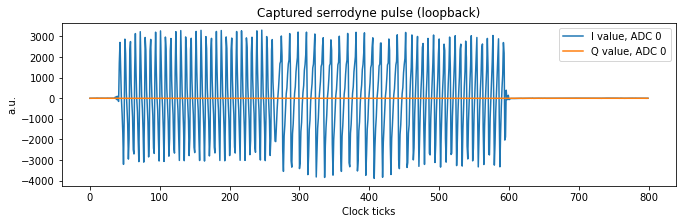

In [21]:
plt.figure(figsize=(11, 3))
for ii, iq in enumerate(iq_list):
    plt.plot(iq[0], label="I value, ADC %d" % (config["ro_chs"][ii]))
    plt.plot(iq[1], label="Q value, ADC %d" % (config["ro_chs"][ii]))
    # plt.plot(np.abs(iq[0] + 1j * iq[1]), label="mag, ADC %d" % (config["ro_chs"][ii]))
plt.ylabel("a.u.")
plt.xlabel("Clock ticks")
plt.title("Captured serrodyne pulse (loopback)")
# plt.xlim(200,300)
plt.legend()

Number of samples: 800
IQ sample rate: 552.96 MHz
FFT resolution: 0.691 MHz
Frequency range: ±276.48 MHz


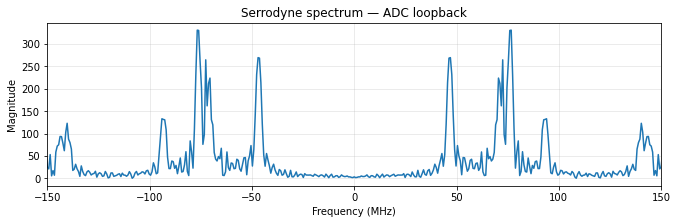

In [22]:
# Build complex IQ trace
iq = iq_list[0]

I = np.asarray(iq[0])
Q = np.asarray(iq[1])

z = I + 1j * Q
N = len(z)

# Effective sample rate of the captured IQ data
fs_iq = soccfg["readouts"][RO_CH]["f_output"] * 1e6  # 552.96 MHz

# FFT of complex IQ signal
spectrum = np.fft.fftshift(np.abs(np.fft.fft(z))) / N

# Frequency axis
freqs_mhz = (
    np.fft.fftshift(
        np.fft.fftfreq(N, d=1 / fs_iq)
    ) / 1e6
)

print(f"Number of samples: {N}")
print(f"IQ sample rate: {fs_iq / 1e6:.2f} MHz")
print(f"FFT resolution: {fs_iq / N / 1e6:.3f} MHz")
print(f"Frequency range: ±{fs_iq / 2 / 1e6:.2f} MHz")

# Plot
plt.figure(figsize=(11, 3))

plt.plot(freqs_mhz, spectrum)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude")
plt.title("Serrodyne spectrum — ADC loopback")

plt.grid(True, alpha=0.3)
plt.xlim(-150, 150)

plt.show()

Number of samples: 9840
Sample spacing: 0.102 ns
Sample rate: 9830.40 MHz
FFT resolution: 0.999 MHz
Frequency range: ±4915.20 MHz


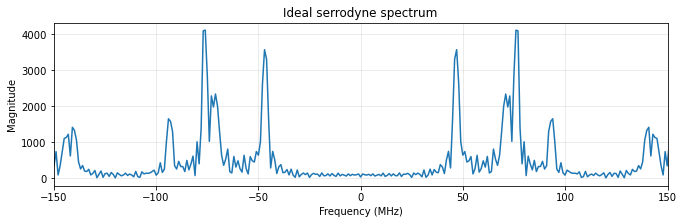

In [23]:
# Ideal signal
signal = np.asarray(idata)
t_ns = np.asarray(t_ns)

N = len(signal)

# Sample spacing and sample rate
dt = (t_ns[1] - t_ns[0]) * 1e-9
fs = 1 / dt

# FFT
spectrum = np.fft.fftshift(np.abs(np.fft.fft(signal))) / N

# Frequency axis
freqs_mhz = (
    np.fft.fftshift(
        np.fft.fftfreq(N, d=dt)
    ) / 1e6
)

print(f"Number of samples: {N}")
print(f"Sample spacing: {dt * 1e9:.3f} ns")
print(f"Sample rate: {fs / 1e6:.2f} MHz")
print(f"FFT resolution: {fs / N / 1e6:.3f} MHz")
print(f"Frequency range: ±{fs / 2 / 1e6:.2f} MHz")

# Plot
plt.figure(figsize=(11, 3))

plt.plot(freqs_mhz, spectrum)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude")
plt.title("Ideal serrodyne spectrum")

plt.grid(True, alpha=0.3)
plt.xlim(-150, 150)

plt.show()

Active window: samples [42:596] out of 800 captured (554 active, 246 dead-time samples trimmed)
Number of samples: 554
Sample rate: 0.553 GS/s
FFT resolution: 0.998 MHz
Frequency range: ±276.48 MHz


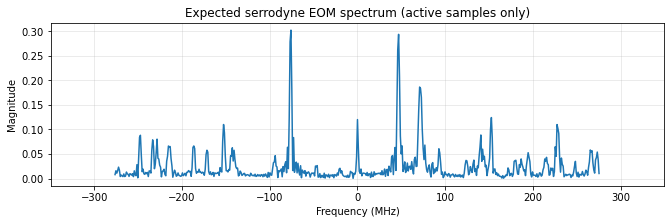

<AxesSubplot:title={'center':'Expected serrodyne EOM spectrum (active samples only)'}, xlabel='Frequency (MHz)', ylabel='Magnitude'>

In [24]:
def plot_eom_spectrum(phase_codes, sample_rate, title="Expected EOM spectrum"):
    data = np.asarray(phase_codes, dtype=float)

    span = float(np.max(data) - np.min(data))
    if span == 0.0:
        raise ValueError("Cannot plot spectrum for a constant waveform")

    # Convert waveform to instantaneous phase [rad] (this nonlinear remap is what lets us
    # see the correct sign, unlike a plain magnitude FFT of the real captured samples)
    phase = 2 * np.pi * (data - np.min(data)) / span

    # Complex field after phase modulation
    field = np.exp(1j * phase)

    N = len(field)

    # FFT
    spectrum = np.fft.fftshift(
        np.abs(np.fft.fft(field))
    ) / N

    # Frequency axis
    freqs_mhz = (
        np.fft.fftshift(
            np.fft.fftfreq(N, d=1 / sample_rate)
        ) / 1e6
    )

    print(f"Number of samples: {N}")
    print(f"Sample rate: {sample_rate / 1e9:.3f} GS/s")
    print(f"FFT resolution: {sample_rate / N / 1e6:.3f} MHz")
    print(f"Frequency range: \u00b1{sample_rate / 2 / 1e6:.2f} MHz")

    # Plot
    fig, ax = plt.subplots(figsize=(11, 3))

    ax.plot(freqs_mhz, spectrum)

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Magnitude")
    ax.set_title(title)

    ax.grid(True, alpha=0.3)
    ax.set_xlim(-350, 350)  # widened so harmonics of the -100 MHz segment are visible too

    plt.show()

    return ax


# FIX: trim to just the active (pulse-on) samples before analyzing.
# readout_length=800 ticks is deliberately longer than the ~1us serrodyne pulse, so the
# captured buffer contains dead-time/baseline samples before and after the pulse. Feeding
# those into the phase-code -> field reconstruction above corrupts the min/max normalization
# and injects spurious edge transients into the spectrum -- that was the "wrong sampling" bug.
I_captured = np.asarray(iq_list[0][0], dtype=float)
threshold = 0.2 * np.max(np.abs(I_captured))
active_idx = np.where(np.abs(I_captured) > threshold)[0]
if len(active_idx) == 0:
    raise RuntimeError("No samples above threshold -- check loopback cabling / gain / threshold.")
i0, i1 = active_idx[0], active_idx[-1] + 1
I_active = I_captured[i0:i1]

print(f"Active window: samples [{i0}:{i1}] out of {len(I_captured)} captured "
      f"({len(I_active)} active, {len(I_captured) - len(I_active)} dead-time samples trimmed)")

fs_readout = soccfg["readouts"][RO_CH]["f_output"] * 1e6

plot_eom_spectrum(
    I_active,
    fs_readout,
    title="Expected serrodyne EOM spectrum (active samples only)"
)